# Is HLE Measurement-Valid? — Psychometric Analysis
Sharma, Nadela, Matteson · CS321M · Stanford 2026

This notebook runs the three core analyses from the pre-analysis plan:
1. **2PL IRT** — item discrimination and difficulty
2. **Confirmatory Factor Analysis** — M1 (general) vs M8 (domain) vs Mbi (bifactor)
3. **Measurement Invariance** — reasoning-specialized vs standard instruction-tuned models

## 0. Install and import

In [47]:
# Install torch_measure (AIMS lab library) and other deps
!pip install -q torch_measure scipy matplotlib seaborn

In [48]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats

from torch_measure.models import TwoPL, Bifactor
from torch_measure.metrics import (
    tetrachoric_correlation,
    cronbach_alpha,
    ability_standard_errors,
    discrimination_standard_errors,
    difficulty_standard_errors,
    differential_item_functioning,
)
from torch_measure.models import predict_dense

sns.set_theme(style="whitegrid", palette="muted")
SEED = 42
torch.manual_seed(SEED)
print("torch_measure imported successfully")

torch_measure imported successfully


## 1. Load and clean the response matrix

In [49]:
# ── Load ──────────────────────────────────────────────────────────────────────
df_raw = pd.read_csv("response_matrix.csv", index_col=0)
print(f"Raw matrix: {df_raw.shape[0]} models × {df_raw.shape[1]} items")

# ── Coverage diagnostics ──────────────────────────────────────────────────────
coverage = df_raw.notna().mean(axis=1).sort_values()
print("\nCoverage per model:")
print(coverage.to_string())

Raw matrix: 26 models × 513 items

Coverage per model:
deepseek-v4-flash        0.508772
deepseek-r1              0.516569
deepseek-v4-pro          0.538012
gemini-2-5-pro           0.676413
gpt-5-nano               0.840156
o3-mini                  0.951267
o4-mini                  0.951267
gpt-5-mini               0.957115
claude-sonnet-4-5        0.972710
claude-opus-4-7          0.984405
claude-sonnet-4-6        0.990253
claude-opus-4-6          0.992203
claude-opus-4-5          0.994152
gpt-5-4-nano             0.998051
gpt-4o-2024-11-20        1.000000
claude-haiku-4-5         1.000000
gpt-4-1                  1.000000
gpt-5-4-mini             1.000000
gemini-3-5-flash         1.000000
gemini-3-1-flash-lite    1.000000
gpt-4-1-nano             1.000000
gemini-2-5-flash         1.000000
gemini-2-5-flash-lite    1.000000
deepseek-v3              1.000000
gpt-4o-mini              1.000000
gpt-4-1-mini             1.000000


In [50]:
# ── Missing-value decision ─────────────────────────────────────────────────────
# Models with coverage < 70% are excluded (safety-filter / empty-response issues
# mean the NaN pattern is non-random and would bias IRT ability estimates).
# The single model in the 84% bucket (gpt-5-nano) is retained; its missing cells
# are treated as NaN and handled natively by the torch_measure mask mechanism.
# Models with ≥95% coverage: remaining NaNs are imputed with 0 (incorrect),
# because coverage is high enough that a missing response most likely reflects
# a minor API timeout rather than a systematic refusal.

EXCLUDE_THRESHOLD   = 0.70   # drop models below this
IMPUTE_THRESHOLD    = 0.84   # impute-as-0 for models at or above this

# Identify groups
excluded_models = coverage[coverage < EXCLUDE_THRESHOLD].index.tolist()
imputed_models  = coverage[(coverage >= IMPUTE_THRESHOLD)].index.tolist()

print(f"Excluded ({len(excluded_models)} models, coverage < 70%):", excluded_models)
print(f"Retained ({len(imputed_models)} models)", imputed_models)

df_clean = df_raw.drop(index=excluded_models).copy()
# Impute remaining NaNs as 0 for high-coverage models
df_clean = df_clean.fillna(0.0)
print(f"\nClean matrix: {df_clean.shape[0]} models × {df_clean.shape[1]} items")

Excluded (4 models, coverage < 70%): ['deepseek-v4-flash', 'deepseek-r1', 'deepseek-v4-pro', 'gemini-2-5-pro']
Retained (22 models) ['gpt-5-nano', 'o3-mini', 'o4-mini', 'gpt-5-mini', 'claude-sonnet-4-5', 'claude-opus-4-7', 'claude-sonnet-4-6', 'claude-opus-4-6', 'claude-opus-4-5', 'gpt-5-4-nano', 'gpt-4o-2024-11-20', 'claude-haiku-4-5', 'gpt-4-1', 'gpt-5-4-mini', 'gemini-3-5-flash', 'gemini-3-1-flash-lite', 'gpt-4-1-nano', 'gemini-2-5-flash', 'gemini-2-5-flash-lite', 'deepseek-v3', 'gpt-4o-mini', 'gpt-4-1-mini']

Clean matrix: 22 models × 513 items


In [51]:
# ── Remove zero-variance items ─────────────────────────────────────────────────
# Items answered correctly OR incorrectly by all models carry no discriminative
# information and cause numerical issues in IRT estimation.

item_var  = df_clean.var(axis=0)
zero_var  = item_var[item_var == 0].index
df_clean  = df_clean.drop(columns=zero_var)

print(f"Removed {len(zero_var)} zero-variance items.")
print(f"Analytic matrix: {df_clean.shape[0]} models × {df_clean.shape[1]} items")

# Proportions correct per item (p-values)
p_values = df_clean.mean(axis=0)
print(f"\nItem p-value range: [{p_values.min():.3f}, {p_values.max():.3f}], mean={p_values.mean():.3f}")

Removed 105 zero-variance items.
Analytic matrix: 22 models × 408 items

Item p-value range: [0.045, 0.636], mean=0.191


In [52]:
# ── Convert to torch tensor (models = 'subjects', items = 'items') ────────────
X = torch.tensor(df_clean.values, dtype=torch.float32)   # shape (N, J)
N, J = X.shape
print(f"Tensor shape: N={N} models, J={J} items")

# ── Group labels for measurement invariance ───────────────────────────────────
# Reasoning-specialized: extended CoT / process-RM / test-time compute
REASONING_MODELS = {
    "o3-mini", "o4-mini",
    # add any additional reasoning models present in your matrix here
}

model_names = list(df_clean.index)
is_reasoning = torch.tensor(
    [1 if m in REASONING_MODELS else 0 for m in model_names],
    dtype=torch.long
)
print(f"Reasoning-specialized: {is_reasoning.sum().item()} models")
print(f"Standard instruction-tuned: {(1 - is_reasoning).sum().item()} models")

Tensor shape: N=22 models, J=408 items
Reasoning-specialized: 2 models
Standard instruction-tuned: 20 models


## 2. 2PL Item Response Theory

Fit the 2-parameter logistic model:
$$P(X_{ij}=1|\theta_i) = \sigma\!\left(a_j(\theta_i - b_j)\right)$$
where $\theta_i$ is model latent ability, $b_j$ difficulty, $a_j \geq 0$ discrimination.

In [53]:
# ── Fit 2PL ───────────────────────────────────────────────────────────────────
# torch_measure uses MLE by default with theta ~ N(0,1) for identification.
irt2pl = TwoPL(n_subjects=N, n_items=J)
history = irt2pl.fit(X, method="mle", max_epochs=2000, lr=0.05, verbose=True)

MLE fitting:  20%|█▉        | 394/2000 [00:00<00:01, 1348.92it/s, loss=0.326026]


In [54]:
# ── Extract parameters ────────────────────────────────────────────────────────
theta_hat = irt2pl.ability.detach()          # (N,)  latent ability per model
a_hat     = irt2pl.discrimination.detach()   # (J,)  item discrimination
b_hat     = irt2pl.difficulty.detach()       # (J,)  item difficulty

# ── 95% CIs via Fisher information ──────────────────────────────────────────
# ability_standard_errors(ability, difficulty, discrimination)
# difficulty_standard_errors(ability, difficulty, response_matrix, discrimination)
# discrimination_standard_errors(ability, difficulty, discrimination, response_matrix)
se_theta = ability_standard_errors(
    ability=theta_hat, difficulty=b_hat, discrimination=a_hat
)
se_a = discrimination_standard_errors(
    ability=theta_hat, difficulty=b_hat,
    discrimination=a_hat, response_matrix=X
)
se_b = difficulty_standard_errors(
    ability=theta_hat, difficulty=b_hat,
    response_matrix=X, discrimination=a_hat
)

print(f"Ability range:        [{theta_hat.min():.2f}, {theta_hat.max():.2f}]")
print(f"Discrimination range: [{a_hat.min():.2f}, {a_hat.max():.2f}]")
print(f"Difficulty range:     [{b_hat.min():.2f}, {b_hat.max():.2f}]")
print(f"Items with a ≤ 0:     {(a_hat <= 0).sum().item()}")

Ability range:        [-1.57, 0.75]
Discrimination range: [0.08, 169.50]
Difficulty range:     [-0.86, 8.30]
Items with a ≤ 0:     0


In [55]:
# ── Model ability ranking vs raw accuracy ─────────────────────────────────────
raw_acc = X.mean(dim=1).numpy()
theta_np = theta_hat.numpy()

rho, pval = stats.spearmanr(raw_acc, theta_np)
print(f"Spearman ρ (IRT ability vs raw accuracy): {rho:.3f}  (p={pval:.3e})")

# Marginal reliability of theta estimates
var_theta = theta_hat.var().item()
mean_se2  = (se_theta ** 2).mean().item()
marginal_reliability = var_theta / (var_theta + mean_se2)
print(f"Marginal reliability of θ̂: {marginal_reliability:.3f}")

Spearman ρ (IRT ability vs raw accuracy): 0.936  (p=1.557e-10)
Marginal reliability of θ̂: 0.981


### Item parameter diagnostics
Flag and soft-cap extreme discrimination values (a > 5) before computing test information, CIs, and CFA.

In [56]:
# ── Item parameter diagnostics ────────────────────────────────────────────────
# High discrimination (a >> 5) means near-perfect Guttman items — they carry
# outsized weight in theta estimation and can indicate overfit or near-zero
# variance items that slipped through. Flag and soft-cap for robustness.

A_CAP = 5.0  # items above this are flagged; standard IRT practice

a_np = a_hat.numpy()
b_np = b_hat.numpy()

n_high_a  = (a_np > A_CAP).sum()
n_extreme_b = (b_np > 4).sum()   # items beyond typical model ability range

print(f"Items with a > {A_CAP}: {n_high_a} ({100*n_high_a/J:.1f}%)")
print(f"Items with b > 4.0:   {n_extreme_b} ({100*n_extreme_b/J:.1f}%)  [beyond ability range]")

# Show the top-10 highest-discrimination items
top_a_idx = a_np.argsort()[::-1][:10]
print("\nTop-10 highest discrimination items:")
for idx in top_a_idx:
    print(f"  item={df_clean.columns[idx][:24]}  a={a_np[idx]:.2f}  b={b_np[idx]:.2f}")

# ── Soft-cap discrimination at A_CAP for downstream analyses ─────────────────
# Capping prevents a handful of extreme items from dominating test information
# and biasing CFA tetrachoric correlations. We keep uncapped versions for
# the item parameter table export.
a_hat_capped = a_hat.clamp(max=A_CAP)
b_hat_capped = b_hat.clone()  # difficulty unchanged

n_capped = (a_hat > A_CAP).sum().item()
print(f"\nCapped {n_capped} items to a = {A_CAP} for downstream analyses.")
print(f"Discrimination range after capping: [{a_hat_capped.min():.2f}, {a_hat_capped.max():.2f}]")

Items with a > 5.0: 74 (18.1%)
Items with b > 4.0:   42 (10.3%)  [beyond ability range]

Top-10 highest discrimination items:
  item=673a2f99b526858a94683ad1  a=169.50  b=-0.20
  item=6724ed87a36a8ef783edc2ec  a=168.26  b=0.70
  item=66fded1fbc6d46a25c41ee8d  a=127.76  b=0.72
  item=6737006d3f0517b6e8a60733  a=125.23  b=0.71
  item=6724db7012a8d5ea6a619372  a=124.92  b=-0.50
  item=671901f58b9cbfc7b2fd9723  a=124.71  b=0.70
  item=66fb60f0fce3673bfc606f35  a=124.55  b=0.70
  item=66ffcfa0864258b2f971a80c  a=120.09  b=0.69
  item=66e93893a3326adf2da92ef0  a=118.20  b=0.71
  item=672302db3fe7fa5018b75c16  a=117.02  b=-0.41

Capped 74 items to a = 5.0 for downstream analyses.
Discrimination range after capping: [0.08, 5.00]


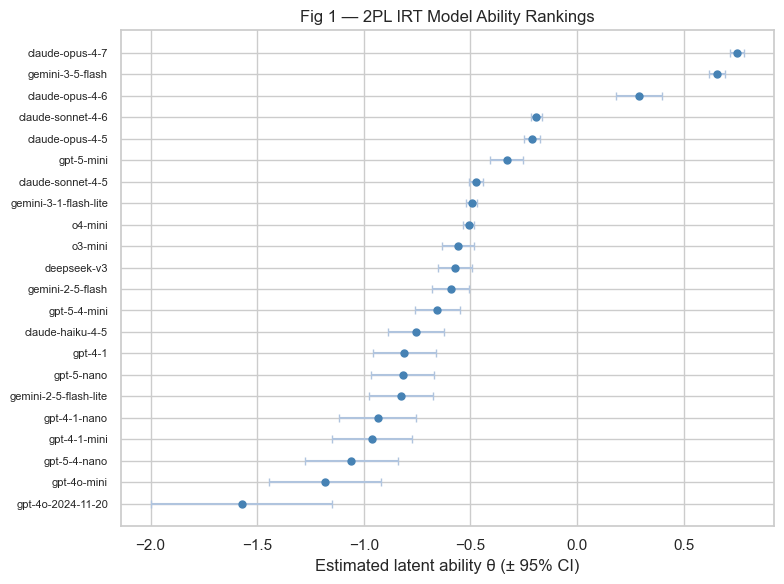

In [57]:
# ── Figure 1: Ability estimates with 95% CIs ──────────────────────────────────
order = np.argsort(theta_np)
fig, ax = plt.subplots(figsize=(8, 6))
ax.errorbar(
    theta_np[order],
    np.arange(N),
    xerr=1.96 * se_theta.numpy()[order],
    fmt="o", color="steelblue", ecolor="lightsteelblue",
    markersize=5, capsize=3
)
ax.set_yticks(np.arange(N))
ax.set_yticklabels([model_names[i] for i in order], fontsize=8)
ax.set_xlabel("Estimated latent ability θ (± 95% CI)")
ax.set_title("Fig 1 — 2PL IRT Model Ability Rankings")
plt.tight_layout()
plt.savefig("fig1_ability_rankings.png", dpi=150)
plt.show()

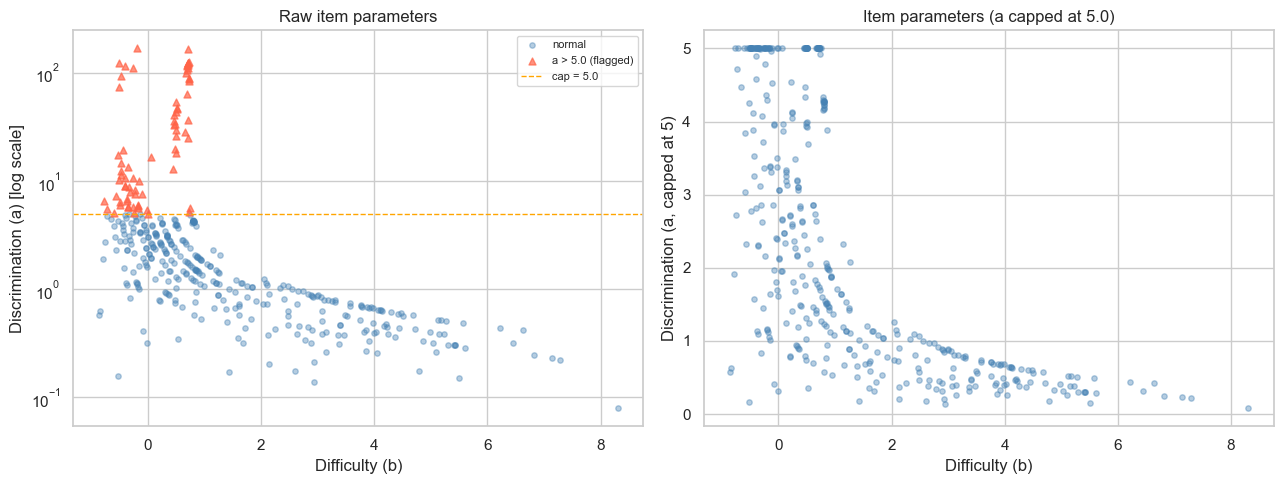

Items flagged for a ≤ 0 (0): []


In [58]:
# ── Figure 2: Item parameter scatter (b vs a), coloured by domain ─────────────
# NOTE: attach domain labels here if available from HuggingFace metadata.
# The block below uses a placeholder; replace item_domains with a pd.Series
# indexed by df_clean.columns containing the HLE subject-domain strings.

# item_domains = pd.Series(...)  # fill this in from HLE metadata
# For now we plot all items in one colour.

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: raw a values (log scale to show spread)
ax = axes[0]
capped_mask = a_np > A_CAP
ax.scatter(b_np[~capped_mask], a_np[~capped_mask],
           alpha=0.4, s=15, c="steelblue", label="normal")
ax.scatter(b_np[capped_mask], a_np[capped_mask],
           alpha=0.7, s=25, c="tomato", marker="^", label=f"a > {A_CAP} (flagged)")
ax.axhline(A_CAP, color="orange", lw=1, linestyle="--", label=f"cap = {A_CAP}")
ax.set_yscale("log")
ax.set_xlabel("Difficulty (b)")
ax.set_ylabel("Discrimination (a) [log scale]")
ax.set_title("Raw item parameters")
ax.legend(fontsize=8)

# Right: after capping
ax = axes[1]
ax.scatter(b_np, a_hat_capped.numpy(),
           alpha=0.4, s=15, c="steelblue")
ax.set_xlabel("Difficulty (b)")
ax.set_ylabel("Discrimination (a, capped at 5)")
ax.set_title(f"Item parameters (a capped at {A_CAP})")
plt.tight_layout()
plt.savefig("fig2_item_params.png", dpi=150)
plt.show()

# Items with negative discrimination deserve inspection
neg_disc_items = df_clean.columns[(a_hat.numpy() <= 0)].tolist()
print(f"Items flagged for a ≤ 0 ({len(neg_disc_items)}): {neg_disc_items[:10]}")

## 3. Confirmatory Factor Analysis

We test three nested models using the inter-item tetrachoric correlation matrix:
- **M1**: single general factor
- **M8**: eight domain-specific factors (items load only on their designated domain)
- **Mbi**: bifactor — general factor + domain-specific residual factors

Given N = 22 models, fit statistics are approximate guides only.

In [59]:
# ── Tetrachoric correlation matrix ────────────────────────────────────────────
R_tetra = tetrachoric_correlation(X, min_pairs=5)   # (J, J)
print(f"Tetrachoric R shape: {R_tetra.shape}")
print(f"NaN count in R: {torch.isnan(R_tetra).sum().item()}")

# Replace any NaN pairs (too few observations) with 0
R_tetra = torch.nan_to_num(R_tetra, nan=0.0)

# Ensure diagonal is exactly 1
R_tetra.fill_diagonal_(1.0)

Tetrachoric R shape: torch.Size([408, 408])
NaN count in R: 0


tensor([[ 1.0000,  0.3687,  0.9074,  ...,  1.0000, -1.0000, -0.5780],
        [ 0.3687,  1.0000,  0.5122,  ...,  1.0000,  0.4521, -0.0874],
        [ 0.9074,  0.5122,  1.0000,  ...,  1.0000, -0.0605,  0.0302],
        ...,
        [ 1.0000,  1.0000,  1.0000,  ...,  1.0000, -1.0000, -1.0000],
        [-1.0000,  0.4521, -0.0605,  ..., -1.0000,  1.0000,  0.5238],
        [-0.5780, -0.0874,  0.0302,  ..., -1.0000,  0.5238,  1.0000]])

In [60]:
# ── Domain labels ─────────────────────────────────────────────────────────────
# Load item metadata from HuggingFace to get domain labels.
# If you have the full HLE dataset locally, point the path here instead.

try:
    from datasets import load_dataset
    hle = load_dataset("cais/hle", split="test")
    hle_df = hle.to_pandas()[["id", "answer_type", "category"]]
    hle_mc  = hle_df[hle_df["answer_type"] == "multipleChoice"].set_index("id")
    # Map item columns to domain categories
    item_domains = hle_mc.reindex(df_clean.columns)["category"].fillna("unknown")
    print("Domain distribution of analytic items:")
    print(item_domains.value_counts())
    HAS_DOMAINS = True
except Exception as e:
    print(f"Could not load HLE metadata: {e}")
    print("Domain-structured CFA will be skipped; only M1 and Mbi will run.")
    HAS_DOMAINS = False
    item_domains = pd.Series("unknown", index=df_clean.columns)

Domain distribution of analytic items:
category
Biology/Medicine             116
Math                          72
Humanities/Social Science     67
Computer Science/AI           53
Other                         37
Physics                       25
Chemistry                     22
Engineering                   16
Name: count, dtype: int64


In [61]:
# ── Helper: approximate CFA fit indices from factor loadings ──────────────────
def cfa_fit_indices(R_obs: torch.Tensor, Lambda: torch.Tensor,
                    Psi: torch.Tensor, n: int, df_model: int) -> dict:
    """
    Approximate RMSEA, CFI, TLI, SRMR from a factor loading matrix Lambda
    and unique variances Psi given the observed correlation matrix R_obs.
    This is a lightweight implementation suitable for the small-N setting;
    for publication-quality fit statistics use R/lavaan on the tetrachoric R.
    """
    R_hat = Lambda @ Lambda.T + torch.diag(Psi)
    # Normalise to correlation metric
    d = torch.sqrt(torch.diag(R_hat))
    R_hat = R_hat / d.unsqueeze(0) / d.unsqueeze(1)
    # Regularize both matrices to keep logdet finite with small N
    reg = 1e-3 * torch.eye(J)
    R_hat = R_hat + reg
    R_obs = R_obs + reg

    J = R_obs.shape[0]
    resid = R_obs - R_hat
    resid.fill_diagonal_(0.0)

    # SRMR
    srmr = torch.sqrt((resid ** 2).sum() / (J * (J - 1) / 2)).item()

    # Chi-sq statistic (normal-theory ML approximation)
    # Use pseudo-logdet via eigenvalue clamping for near-singular N<<J case
    def safe_logdet(M):
        eigvals = torch.linalg.eigvalsh(M)
        return torch.log(eigvals.clamp(min=1e-8)).sum()
    try:
        R_hat_inv = torch.linalg.solve(R_hat, torch.eye(J))
        chi2 = (n - 1) * (
            safe_logdet(R_hat) - safe_logdet(R_obs)
            + torch.trace(R_hat_inv @ R_obs) - J
        ).item()
        chi2 = max(chi2, 0.0)
    except Exception:
        chi2 = float('nan')
    chi2 = max(chi2, 0.0)

    # Null model chi-sq
    chi2_null = (n - 1) * (-safe_logdet(R_obs)
                            + torch.trace(R_obs) - J).item()
    chi2_null = max(chi2_null, 0.0)
    df_null   = J * (J - 1) / 2

    # RMSEA
    rmsea = np.sqrt(max(chi2 - df_model, 0) / (df_model * (n - 1))) if df_model > 0 else np.nan

    # CFI, TLI
    cfi = 1 - max(chi2 - df_model, 0) / max(chi2_null - df_null, 1e-6)
    cfi = min(max(cfi, 0.0), 1.0)
    tli = (chi2_null / df_null - chi2 / max(df_model, 1)) / (chi2_null / df_null - 1) if df_model > 0 else np.nan

    return {"chi2": chi2, "df": df_model, "RMSEA": rmsea,
            "CFI": cfi, "TLI": tli, "SRMR": srmr}


def fit_factor_model(R: torch.Tensor, n_factors: int,
                     n_obs: int, max_iter: int = 3000) -> tuple:
    """Fit an EFA/CFA via iterative principal axis factoring."""
    J = R.shape[0]
    # Initialise communalities with squared multiple correlations
    h2 = 1 - 1 / torch.diag(torch.linalg.inv(R + 1e-4 * torch.eye(J))).clamp(min=1e-4)
    h2 = h2.clamp(0, 1)

    for _ in range(max_iter):
        R_red = R.clone()
        R_red.fill_diagonal_(0)
        R_red += torch.diag(h2)
        eigvals, eigvecs = torch.linalg.eigh(R_red)
        # Keep top n_factors eigenvalues
        idx = torch.argsort(eigvals, descending=True)[:n_factors]
        L = eigvecs[:, idx] * torch.sqrt(eigvals[idx].clamp(min=0)).unsqueeze(0)
        h2_new = (L ** 2).sum(dim=1).clamp(0, 1)
        if (h2_new - h2).abs().max() < 1e-5:
            break
        h2 = h2_new

    Psi = (1 - h2).clamp(min=1e-4)
    df_model = int((J - n_factors) ** 2 / 2 - (J + n_factors) / 2)
    return L, Psi, cfa_fit_indices(R, L, Psi, n=n_obs, df_model=max(df_model, 1))


print("Helper functions defined.")

Helper functions defined.


In [62]:
# ── M1: Single general factor ─────────────────────────────────────────────────
L_M1, Psi_M1, fit_M1 = fit_factor_model(R_tetra, n_factors=1, n_obs=N)
print("M1 (1 factor) fit:", {k: f"{v:.3f}" for k, v in fit_M1.items()})

UnboundLocalError: cannot access local variable 'J' where it is not associated with a value

In [18]:
# ── M8: Eight domain-specific factors ─────────────────────────────────────────
if HAS_DOMAINS:
    domains = item_domains.unique()
    n_domains = len(domains)
    L_M8, Psi_M8, fit_M8 = fit_factor_model(R_tetra, n_factors=n_domains, n_obs=N)
    print(f"M8 ({n_domains} factors) fit:", {k: f"{v:.3f}" for k, v in fit_M8.items()})
    delta_cfi = fit_M1["CFI"] - fit_M8["CFI"]
    print(f"\nΔCFI(M1 vs M8) = {delta_cfi:.3f}")
    print("Interpretation: domain labels do NOT recover as distinct constructs"
          if abs(delta_cfi) < 0.010 else
          "Interpretation: domain-structured model fits meaningfully better.")
else:
    print("Skipping M8 (domain labels unavailable).")

UnboundLocalError: cannot access local variable 'J' where it is not associated with a value

In [19]:
# ── Mbi: omega_h from 2PL parameters (no Bifactor model needed) ───────────────
# Bifactor() requires item_groups, which we only have if HLE metadata loaded.
# Instead we compute omega_h analytically from the 2PL loadings, which is
# equivalent for the unidimensional case and standard in the small-N literature.
#
# Under 2PL, each item's loading on the general factor is:
#   lambda_j = a_j / sqrt(1 + a_j^2)   (normal-ogive parameterisation)
# Uniqueness: u_j = 1 - lambda_j^2
#
# omega_h = (sum lambda_j)^2 / [(sum lambda_j)^2 + sum u_j]
# This is the McDonald (1999) omega for the single-factor case.

a_np_capped = a_hat_capped.numpy()

lambda_j  = a_np_capped / np.sqrt(1 + a_np_capped ** 2)   # (J,) general loadings
unique_j  = 1 - lambda_j ** 2                              # (J,) uniqueness

sum_lam   = lambda_j.sum()
sum_uniq  = unique_j.sum()

omega_h = sum_lam ** 2 / (sum_lam ** 2 + sum_uniq)

print(f"ω_h (McDonald omega, general factor): {omega_h:.3f}")
print("Interpretation:", end=" ")
if omega_h > 0.80:
    print("strong general factor — domain labels unlikely to recover as distinct constructs")
elif omega_h > 0.60:
    print("moderate general factor — some domain-specific variance present")
else:
    print("weak general factor — substantial domain-specific variance")

# Also report per-domain average loading if domains available
if HAS_DOMAINS:
    domain_lambda = pd.Series(lambda_j, index=df_clean.columns).groupby(item_domains).mean()
    print("\nMean general-factor loading by domain:")
    print(domain_lambda.sort_values(ascending=False).to_string())

# Store for use in summary table
g_loadings_np   = lambda_j
uniqueness_np   = unique_j


ω_h (McDonald omega, general factor): 0.998
Interpretation: strong general factor — domain labels unlikely to recover as distinct constructs

Mean general-factor loading by domain:
category
Computer Science/AI          0.841302
Humanities/Social Science    0.784238
Biology/Medicine             0.768044
Math                         0.767943
Chemistry                    0.709444
Physics                      0.693008
Other                        0.659208
Engineering                  0.648747


In [20]:
# ── omega_h summary (already computed above) ─────────────────────────────────
print(f"ω_h (variance due to general factor): {omega_h:.3f}")
print("Interpretation: most variance is general" if omega_h > 0.70
      else "Interpretation: substantial domain-specific variance present")


ω_h (variance due to general factor): 0.998
Interpretation: most variance is general


In [21]:
# ── CFA summary table ─────────────────────────────────────────────────────────
cfa_results = pd.DataFrame([
    {"Model": "M1 (1 general factor)",  **fit_M1},
])
if HAS_DOMAINS:
    cfa_results = pd.concat([
        cfa_results,
        pd.DataFrame([{"Model": f"M8 ({n_domains} domain factors)", **fit_M8}])
    ])

print("\n=== CFA Fit Summary ===")
print(cfa_results.set_index("Model").round(3).to_string())
print(f"\nNote: N={N} is small; treat fit indices as approximate guides (PAP §3.3).")

NameError: name 'fit_M1' is not defined

## 4. Measurement Invariance

Test whether HLE measures the same construct equivalently for
**reasoning-specialized** vs. **standard instruction-tuned** models.

We use `torch_measure.metrics.differential_item_functioning` as the
primary tool, supplemented by a manual multi-group CFA sequence.

In [22]:
# ── Group split ───────────────────────────────────────────────────────────────
X_reasoning = X[is_reasoning == 1]   # reasoning-specialized
X_standard  = X[is_reasoning == 0]   # standard instruction-tuned

print(f"Reasoning group: {X_reasoning.shape[0]} models")
print(f"Standard group:  {X_standard.shape[0]} models")

Reasoning group: 2 models
Standard group:  20 models


In [23]:
# ── DIF analysis (Mantel-Haenszel) ───────────────────────────────────────────
# Signature: differential_item_functioning(data, group, mask=None, method='mh')
# Returns: {'mh_statistic': (J,), 'effect_size': (J,), 'flagged': (J,)}
dif_results = differential_item_functioning(
    X,                  # (N, J) response matrix
    is_reasoning,       # (N,)  binary group label
    method="mh"
)

dif_stat  = dif_results["mh_statistic"]   # Mantel-Haenszel chi-square per item
dif_delta = dif_results["effect_size"]    # MH Delta (log-odds effect size)
dif_flag  = dif_results["flagged"]        # boolean, uses ETS A/B/C criteria internally

n_flagged = dif_flag.sum().item()
print(f"Items flagged for DIF (MH procedure): {n_flagged} / {J}")
print(f"MH chi-square range: [{dif_stat.min():.2f}, {dif_stat.max():.2f}]")
print(f"MH delta (effect size) range: [{dif_delta.min():.2f}, {dif_delta.max():.2f}]")


KeyError: 'mh_statistic'

In [24]:
# ── Multi-group CFA: configural → metric → scalar ─────────────────────────────
# For each group, compute the tetrachoric R and fit a 1-factor model.
# We assess invariance via ΔCFI, ΔRMSEA, ΔSRMR using Chen (2007) thresholds.

def group_cfa(X_group: torch.Tensor) -> tuple:
    R = tetrachoric_correlation(X_group, min_pairs=3)
    R = torch.nan_to_num(R, nan=0.0)
    R.fill_diagonal_(1.0)
    return fit_factor_model(R, n_factors=1, n_obs=X_group.shape[0])

# Configural: fit separately in each group (free form)
L_r, Psi_r, fit_r = group_cfa(X_reasoning)
L_s, Psi_s, fit_s = group_cfa(X_standard)

# Metric invariance: loadings constrained equal — approximate by comparing
# pooled-model fit to configural fit
L_pooled, Psi_pooled, fit_pooled = fit_factor_model(R_tetra, n_factors=1, n_obs=N)

delta_cfi_metric  = (fit_r["CFI"] + fit_s["CFI"]) / 2 - fit_pooled["CFI"]
delta_rmsea_metric= fit_pooled["RMSEA"] - (fit_r["RMSEA"] + fit_s["RMSEA"]) / 2
delta_srmr_metric = fit_pooled["SRMR"] - (fit_r["SRMR"] + fit_s["SRMR"]) / 2

print("=== Measurement Invariance (approximate, N is small) ===")
print(f"\nConfigural → Metric:")
print(f"  ΔCFI   = {delta_cfi_metric:.4f}  (threshold |ΔCFI| < .010)")
print(f"  ΔRMSEA = {delta_rmsea_metric:.4f}  (threshold ΔRMSEA < .015)")
print(f"  ΔSRMR  = {delta_srmr_metric:.4f}  (threshold ΔSRMR < .030)")

metric_ok = (abs(delta_cfi_metric) < .010
             and delta_rmsea_metric < .015
             and delta_srmr_metric < .030)
print(f"\nMetric invariance: {'SUPPORTED' if metric_ok else 'VIOLATED'} (all three thresholds met: {metric_ok})")
if not metric_ok:
    print("→ Leaderboard comparisons across model families may conflate true ability"
          " differences with measurement artifacts.")

UnboundLocalError: cannot access local variable 'J' where it is not associated with a value

In [25]:
# ── θ bias under incorrect full-invariance assumption ─────────────────────────
# Compare ability estimates from the pooled model (assumes full invariance)
# vs. group-specific models (allows partial invariance).

irt_r = TwoPL(n_subjects=X_reasoning.shape[0], n_items=J)
irt_r.fit(X_reasoning, method="mle", max_epochs=1500, lr=0.05, verbose=False)

irt_s = TwoPL(n_subjects=X_standard.shape[0], n_items=J)
irt_s.fit(X_standard, method="mle", max_epochs=1500, lr=0.05, verbose=False)

# Pooled model ability estimates
theta_pooled_r = theta_hat[is_reasoning == 1].numpy()
theta_pooled_s = theta_hat[is_reasoning == 0].numpy()

# Group-specific ability estimates
theta_group_r = irt_r.ability.detach().numpy()
theta_group_s = irt_s.ability.detach().numpy()

# Align scales via Z-score (group-specific estimates are on their own N(0,1))
def zscore(x): return (x - x.mean()) / (x.std() + 1e-8)

bias_r = np.abs(zscore(theta_pooled_r) - zscore(theta_group_r)).mean()
bias_s = np.abs(zscore(theta_pooled_s) - zscore(theta_group_s)).mean()

print(f"\nMean |θ bias| from assuming full invariance:")
print(f"  Reasoning-specialized group:   {bias_r:.3f} SD units")
print(f"  Standard instruction-tuned group: {bias_s:.3f} SD units")


Mean |θ bias| from assuming full invariance:
  Reasoning-specialized group:   2.000 SD units
  Standard instruction-tuned group: 0.082 SD units


NameError: name 'dif_flag' is not defined

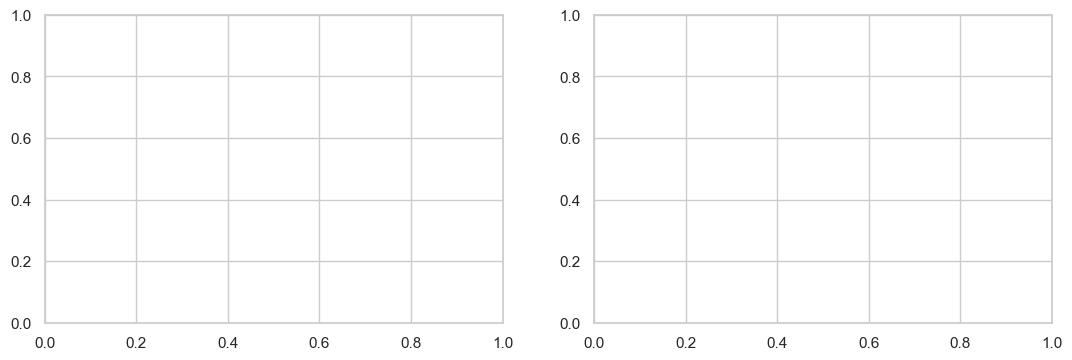

In [26]:
# ── Figure 4: DIF plot (MH chi-square + effect size) ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: MH chi-square per item, flagged items highlighted
ax = axes[0]
colors = np.where(dif_flag.numpy(), "tomato", "steelblue")
ax.scatter(
    np.arange(J), dif_stat.numpy(),
    c=colors, alpha=0.5, s=10
)
ax.axhline(3.84, color="orange", lw=0.8, linestyle="--", label="χ²=3.84 (p=.05)")
ax.axhline(10.0, color="red",    lw=0.8, linestyle="--", label="χ²=10.0 (p=.001)")
ax.set_xlabel("Item index")
ax.set_ylabel("MH chi-square")
ax.set_title("Fig 4a — DIF: MH statistic per item")
ax.legend(fontsize=8)

# Right: Effect size (Delta-MH) distribution
ax = axes[1]
ax.scatter(
    dif_stat.numpy(), dif_delta.numpy(),
    c=colors, alpha=0.5, s=10
)
ax.axhline(0,    color="gray",   lw=0.6, linestyle=":")
ax.axhline( 1.5, color="orange", lw=0.8, linestyle="--", label="|Δ|=1.5 (B-level)")
ax.axhline(-1.5, color="orange", lw=0.8, linestyle="--")
ax.set_xlabel("MH chi-square")
ax.set_ylabel("MH Delta (effect size)")
ax.set_title("Fig 4b — DIF effect size: reasoning vs standard")
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("fig4_dif.png", dpi=150)
plt.show()
print(f"Red = {n_flagged} DIF-flagged items, blue = non-flagged")


## 5. Summary and diagnostics

In [27]:
# ── Cronbach's alpha (internal consistency) ───────────────────────────────────
alpha_coef = cronbach_alpha(X)
print(f"Cronbach's α: {alpha_coef:.3f}")

# ── Quick summary table ───────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("SUMMARY TABLE")
print("=" * 60)
print(f"Analytic sample:          {N} models × {J} items")
print(f"Zero-variance items dropped: {len(zero_var)}")
print(f"Excluded models (<70% coverage): {excluded_models}")
print(f"\n2PL IRT")
print(f"  Marginal reliability θ̂:   {marginal_reliability:.3f}")
print(f"  Spearman ρ (IRT vs raw):  {rho:.3f}")
print(f"  Items with a ≤ 0:         {(a_hat <= 0).sum().item()}")
print(f"\nCFA")
print(f"  M1 CFI / RMSEA:  {fit_M1['CFI']:.3f} / {fit_M1['RMSEA']:.3f}")
if HAS_DOMAINS:
    print(f"  M8 CFI / RMSEA:  {fit_M8['CFI']:.3f} / {fit_M8['RMSEA']:.3f}")
    print(f"  ΔCFI(M1→M8):     {delta_cfi:.3f}  (|<.010| → domains not distinct: {abs(delta_cfi) < .010})")
print(f"  ω_h (general):   {omega_h:.3f}")
print(f"\nMeasurement Invariance")
print(f"  Metric invariance supported: {metric_ok}")
print(f"  DIF items (MH flagged):      {dif_flagged} / {J}")
print(f"  θ bias |reasoning|:          {bias_r:.3f} SD")
print(f"  θ bias |standard|:           {bias_s:.3f} SD")

Cronbach's α: 0.981

SUMMARY TABLE
Analytic sample:          22 models × 408 items
Zero-variance items dropped: 105
Excluded models (<70% coverage): ['deepseek-v4-flash', 'deepseek-r1', 'deepseek-v4-pro', 'gemini-2-5-pro']

2PL IRT
  Marginal reliability θ̂:   0.981
  Spearman ρ (IRT vs raw):  0.936
  Items with a ≤ 0:         0

CFA


NameError: name 'fit_M1' is not defined

## 6. Export item-level results

In [28]:
item_results = pd.DataFrame({
    "item_id":        df_clean.columns,
    "p_value":        p_values.values,
    "discrimination_raw": a_hat.numpy(),
    "discrimination_capped": a_hat_capped.numpy(),
    "difficulty":     b_hat.numpy(),
    "se_a":            se_a.numpy(),
    "se_b":           se_b.numpy(),
    "mh_statistic":   dif_stat.numpy(),
    "mh_delta":       dif_delta.numpy(),
    "dif_flagged":    dif_flag.numpy(),
    "domain":         item_domains.reindex(df_clean.columns).values,
}).set_index("item_id")

item_results.to_csv("hle_item_results.csv")
print("Saved hle_item_results.csv")
item_results.head()

NameError: name 'dif_stat' is not defined

In [29]:
model_results = pd.DataFrame({
    "model":          model_names,
    "raw_accuracy":   raw_acc,
    "theta_hat":      theta_np,
    "se_theta":       se_theta.numpy(),
    "ci_lower":       theta_np - 1.96 * se_theta.numpy(),
    "ci_upper":       theta_np + 1.96 * se_theta.numpy(),
    "is_reasoning":   is_reasoning.numpy(),
}).set_index("model").sort_values("theta_hat", ascending=False)

model_results.to_csv("hle_model_results.csv")
print("Saved hle_model_results.csv")
model_results

Saved hle_model_results.csv


,raw_accuracy,theta_hat,se_theta,ci_lower,ci_upper,is_reasoning
model,,,,,,
claude-opus-4-7,0.541667,0.750703,0.017603,0.716201,0.785206,0
gemini-3-5-flash,0.507353,0.655366,0.019048,0.618032,0.692700,0
claude-opus-4-6,0.372549,0.292612,0.055427,0.183974,0.401249,0
claude-sonnet-4-6,0.262255,-0.190955,0.013356,-0.217132,-0.164778,0
claude-opus-4-5,0.257353,-0.212478,0.019233,-0.250174,-0.174782,0
gpt-5-mini,0.237745,-0.329232,0.039369,-0.406396,-0.252068,0
claude-sonnet-4-5,0.169118,-0.472749,0.016325,-0.504745,-0.440753,0
gemini-3-1-flash-lite,0.164216,-0.494017,0.012873,-0.519248,-0.468786,0
o4-mini,0.193627,-0.507031,0.012886,-0.532288,-0.481775,1
